# Notebook 1 — Autoencoder Foundation & VAE

**Phase 1** deliverable. Learning objectives (see `docs/PROJECT_BRIEF.md`):
- Vanilla autoencoder for image compression
- Denoising autoencoder for image restoration
- Variational Autoencoder (VAE) with the reparameterization trick
- Latent space interpolation & visualization
- Sampling new images from the learned latent distribution

Complete the `# TODO`s in `src/generative_art_studio/models/autoencoders/` and
`src/generative_art_studio/training/losses.py::vae_loss` before running the
training cells below — until then they'll raise `NotImplementedError`,
which is expected mid-course. Run `pytest -m vae -v` to check your progress.


In [22]:
%matplotlib inline

import sys
from pathlib import Path

# Make `generative_art_studio` importable without `pip install -e .`
# REPO_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() else Path.cwd()
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import torch
from generative_art_studio.utils import set_seed, plot_image_grid
from generative_art_studio.config import DEVICE

set_seed(42)
print(f"Using device: {DEVICE}")


Using device: cuda


## Data

We use `SyntheticImageDataset` here so this notebook runs instantly without
a download. **Swap in real CelebA data** once you've downloaded it (see
`docs/SETUP.md`) by replacing this cell with:

```python
from generative_art_studio.data import get_image_dataset, get_dataloader
dataset = get_image_dataset("data/celeba", image_size=64)
dataloader = get_dataloader(dataset, batch_size=64)
```


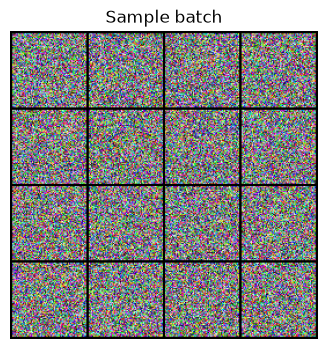

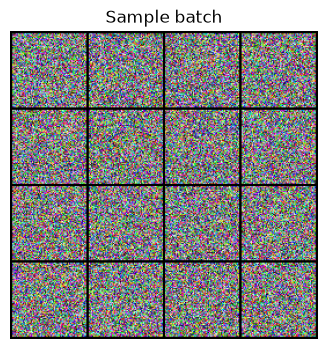

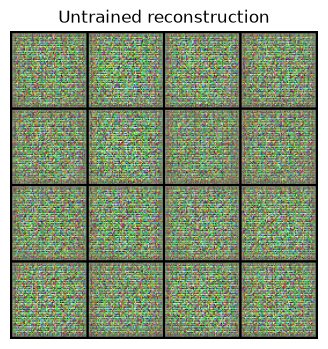

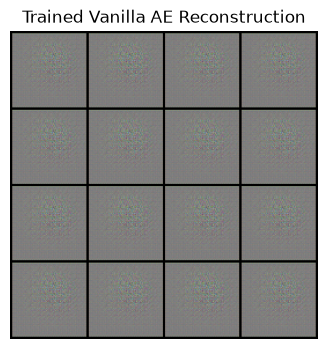

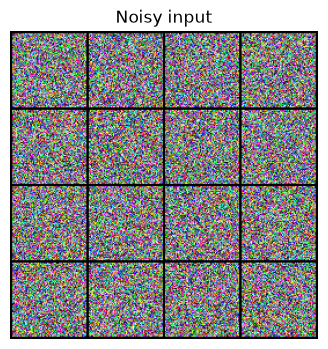

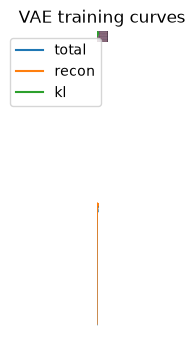

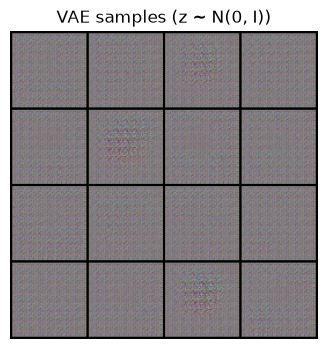

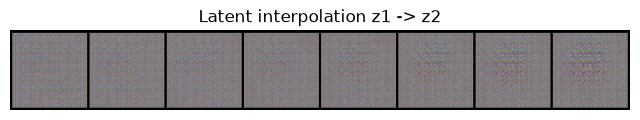

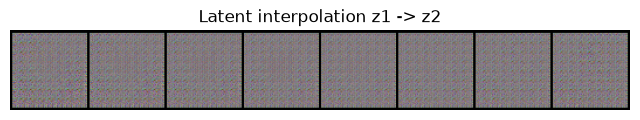

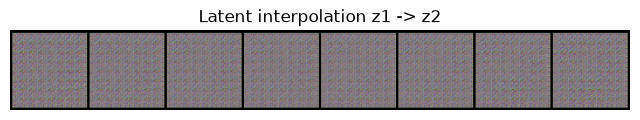

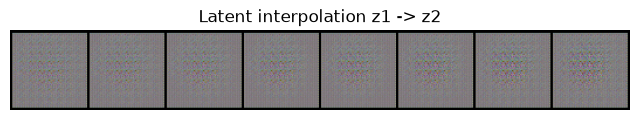

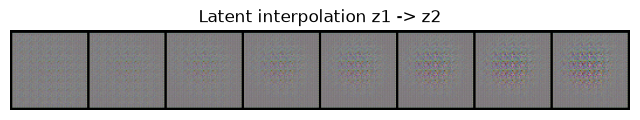

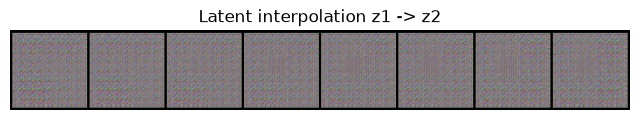

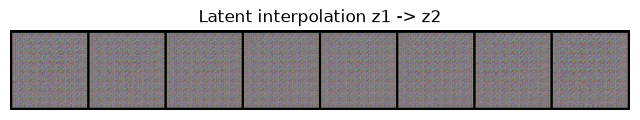

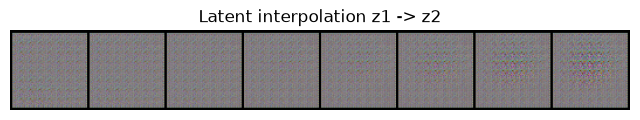

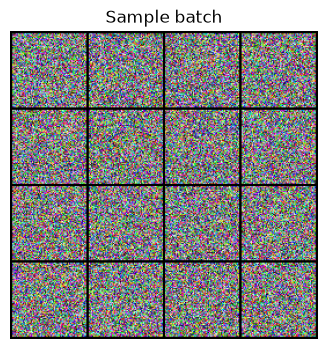

In [23]:
from generative_art_studio.data import SyntheticImageDataset, get_dataloader

dataset = SyntheticImageDataset(num_samples=256, image_size=64)
dataloader = get_dataloader(dataset, batch_size=32)

images, labels = next(iter(dataloader))
fig = plot_image_grid(images[:16], nrow=4, title="Sample batch")
fig


## 1. Vanilla Autoencoder (given, fully implemented — study it first)

Input: torch.Size([32, 3, 64, 64]) -> Reconstruction: torch.Size([32, 3, 64, 64])


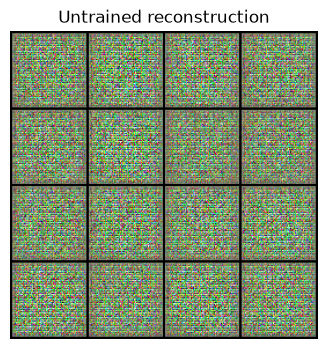

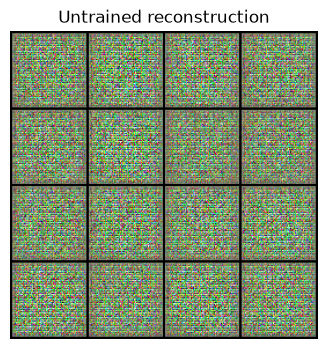

In [24]:
from generative_art_studio.models.autoencoders import VanillaAutoencoder

ae = VanillaAutoencoder(in_channels=3, latent_dim=128).to(DEVICE)
recon = ae(images.to(DEVICE))
print("Input:", images.shape, "-> Reconstruction:", recon.shape)
plot_image_grid(recon[:16].detach().cpu(), nrow=4, title="Untrained reconstruction")


### TODO: train the vanilla autoencoder

Write a short training loop (MSE loss between `ae(images)` and `images`,
Adam optimizer) over a few epochs of `dataloader`, then re-plot
reconstructions. This is ungraded practice — the graded work is the
denoising AE and VAE below.


Epoch 1/3 - Loss: 0.4281
Epoch 2/3 - Loss: 0.3443
Epoch 3/3 - Loss: 0.3381


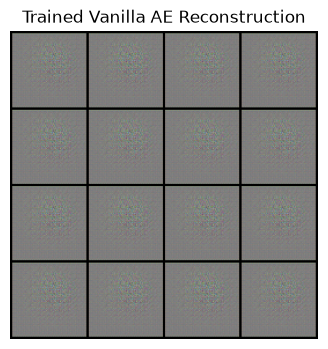

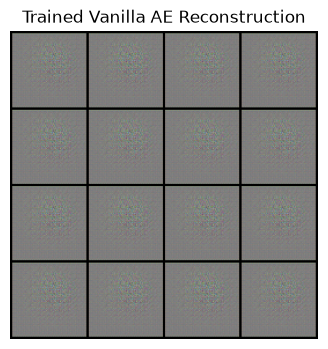

In [25]:
# TODO: your vanilla-AE training loop here
from torch.optim import Adam
import torch.nn as nn

optimizer = Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

ae.train()

for epoch in range(3):
    total_loss = 0.0

    for batch_images, _ in dataloader:
        batch_images = batch_images.to(DEVICE)

        optimizer.zero_grad()

        recon = ae(batch_images)
        loss = criterion(recon, batch_images)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch + 1}/3 - Loss: {avg_loss:.4f}")

ae.eval()

with torch.no_grad():
    recon = ae(images.to(DEVICE))

plot_image_grid(
    recon[:16].detach().cpu(),
    nrow=4,
    title="Trained Vanilla AE Reconstruction"
)

## 2. Denoising Autoencoder

Implement `add_gaussian_noise` in `models/autoencoders/denoising_ae.py` first.

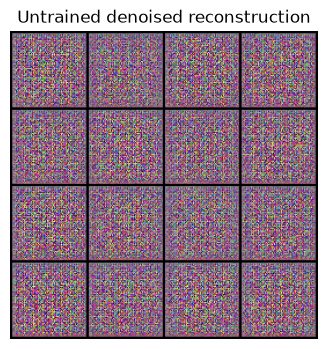

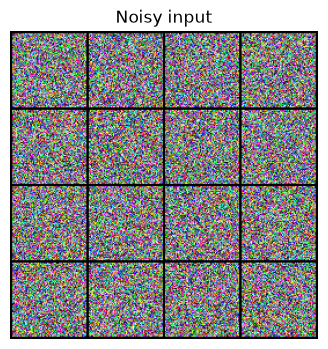

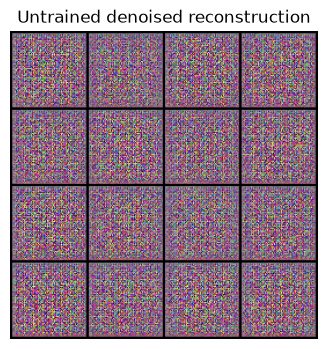

In [26]:
from generative_art_studio.models.autoencoders import DenoisingAutoencoder, add_gaussian_noise

noisy = add_gaussian_noise(images, noise_factor=0.3)
plot_image_grid(noisy[:16], nrow=4, title="Noisy input")

dae = DenoisingAutoencoder(in_channels=3, latent_dim=128, noise_factor=0.3).to(DEVICE)
restored = dae(images.to(DEVICE))
plot_image_grid(restored[:16].detach().cpu(), nrow=4, title="Untrained denoised reconstruction")


## 3. Variational Autoencoder (VAE)

Implement, in order:
1. `VAE.reparameterize` in `models/autoencoders/vae.py`
2. `vae_loss` in `training/losses.py`
3. `interpolate_latent` in `utils/latent_space.py`


In [27]:
from generative_art_studio.models.autoencoders import VAE

vae = VAE(in_channels=3, latent_dim=128).to(DEVICE)
recon, mu, logvar = vae(images.to(DEVICE))
print("recon:", recon.shape, "mu:", mu.shape, "logvar:", logvar.shape)


recon: torch.Size([32, 3, 64, 64]) mu: torch.Size([32, 128]) logvar: torch.Size([32, 128])


### Train the VAE

VAE epoch 1/3:   0%|          | 0/8 [00:00<?, ?it/s]

VAE epoch 2/3:   0%|          | 0/8 [00:00<?, ?it/s]

VAE epoch 3/3:   0%|          | 0/8 [00:00<?, ?it/s]

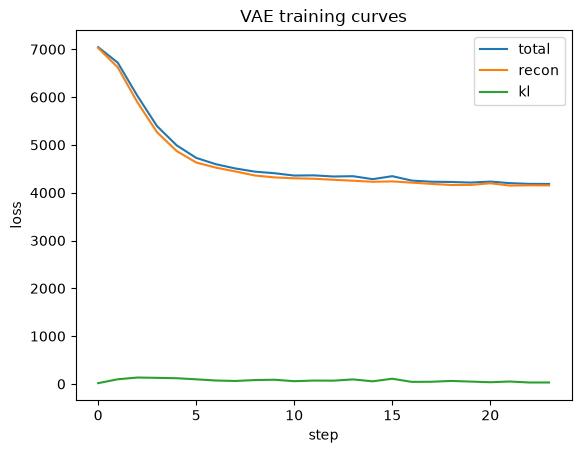

In [28]:
from torch.optim import Adam
from generative_art_studio.training.train_vae import train_vae

optimizer = Adam(vae.parameters(), lr=1e-3)
history = train_vae(vae, dataloader, optimizer, device=DEVICE, epochs=3, kl_weight=1.0)

import matplotlib.pyplot as plt
plt.plot(history.total, label="total")
plt.plot(history.recon, label="recon")
plt.plot(history.kl, label="kl")
plt.legend(); plt.xlabel("step"); plt.ylabel("loss"); plt.title("VAE training curves")
plt.show()


### Sample new images from the learned latent distribution

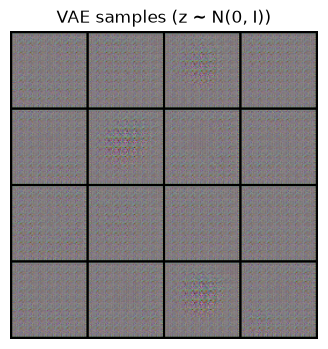

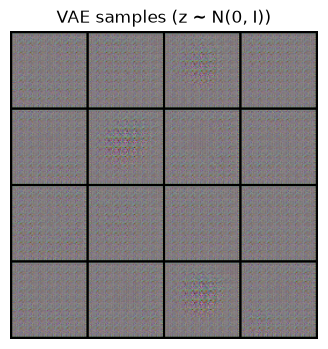

In [29]:
samples = vae.sample(16, device=DEVICE)
plot_image_grid(samples.cpu(), nrow=4, title="VAE samples (z ~ N(0, I))")


### Latent space interpolation

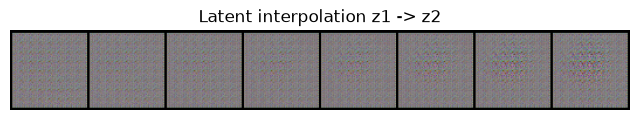

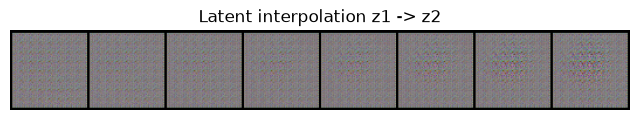

In [30]:
from generative_art_studio.utils.latent_space import interpolate_latent

z1 = torch.randn(vae.latent_dim, device=DEVICE)
z2 = torch.randn(vae.latent_dim, device=DEVICE)
path = interpolate_latent(z1, z2, steps=8)
decoded = vae.decode(path)
plot_image_grid(decoded.detach().cpu(), nrow=8, title="Latent interpolation z1 -> z2")


## Reflection (for your Technical Report)

- How does denoising-AE reconstruction quality compare to the vanilla AE?
- What did the VAE's reconstruction vs. KL loss curves look like — did KL
  collapse (drop to ~0) at any point? What does that mean?
- Describe what you observed walking through latent space: smooth
  transitions, or abrupt jumps? What does that tell you about how
  well-structured the learned latent space is?
